In [1]:
from langgraph.graph import StateGraph, START,END
from typing import TypedDict

In [3]:
class BMIState(StateGraph):

    weight_kg : float
    height_m : float
    bmi : float
    label : str 

In [4]:
def calculate_bmi(state : BMIState) -> BMIState:

    weight = state['weight_kg']
    height = state['height_m']

    bmi = weight/(height**2)
    state['bmi'] = bmi

    return state

In [5]:
def label_bmi(state : BMIState) -> BMIState: 

    state['label'] = "hello junaid"

    return state

In [10]:
graph = StateGraph(BMIState)

node_1 = 'calculate_bmi'
node_2 = 'label_mi'

graph.add_node(node_1,calculate_bmi)
graph.add_node(node_2,label_bmi)

graph.add_edge(START, node_1)
graph.add_edge(node_1,node_2)
graph.add_edge(node_2,END)

workflow = graph.compile()


initial_state = {'weight_kg':80,'height_m':1.73}
result = workflow.invoke(initial_state)

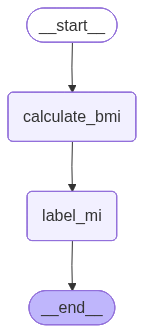

In [8]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [11]:
print(result)

{'weight_kg': 80, 'height_m': 1.73, 'bmi': 26.729927495071667, 'label': 'hello junaid'}
